# 04. Log Transform — log1p 타겟 변환 실험

> **목표**: 타겟 왜도 5.68 → log1p 변환 후 0.08로 감소.  
> LGBM L1(MAE) 최적화 시 대칭 분포에서 더 효과적 → 예상 MAE 10~20% 향상.

## 실험 설계
| 항목 | 내용 |
|---|---|
| CV | GroupKFold(scenario_id, n_splits=5) |
| 베이스라인 | 원본 타겟, GroupKFold OOF MAE |
| 로그 변환 | `log1p(y)` → 학습 → `expm1(pred).clip(0)` 역변환 |
| 비교 지표 | 원본 스케일 MAE (역변환 후 계산) |


## 1. 라이브러리 및 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/'
TARGET = 'avg_delay_minutes_next_30m'
SEED = 42
N_SPLITS = 5

lgb_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'min_child_samples': 20,
    'n_estimators': 1000,
    'early_stopping_rounds': 100,
    'verbose': -1,
    'random_state': SEED,
}
print('설정 완료')


설정 완료


## 2. 데이터 로드 및 전처리

In [2]:
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
layout = pd.read_csv(DATA_PATH + 'layout_info.csv')

train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

EXCLUDE_COLS = ['ID', 'layout_id', 'scenario_id', TARGET]
cat_cols = [c for c in train.select_dtypes(include='object').columns if c not in EXCLUDE_COLS]
for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0)
    mapping = {v: i for i, v in enumerate(combined.dropna().unique())}
    train[col] = train[col].map(mapping)
    test[col]  = test[col].map(mapping)

feature_cols = [c for c in train.columns if c not in EXCLUDE_COLS]
X = train[feature_cols].values
y = train[TARGET].values
y_log = np.log1p(y)  # log 변환 타겟
groups = train['scenario_id'].values
X_test = test[feature_cols].values

print(f'Train: {train.shape}, Features: {len(feature_cols)}')
print(f'y   skewness: {pd.Series(y).skew():.4f}')
print(f'y_log skewness: {pd.Series(y_log).skew():.4f}')


Train: (250000, 108), Features: 104
y   skewness: 5.6821
y_log skewness: 0.0801


## 3. 타겟 분포: 원본 vs log1p

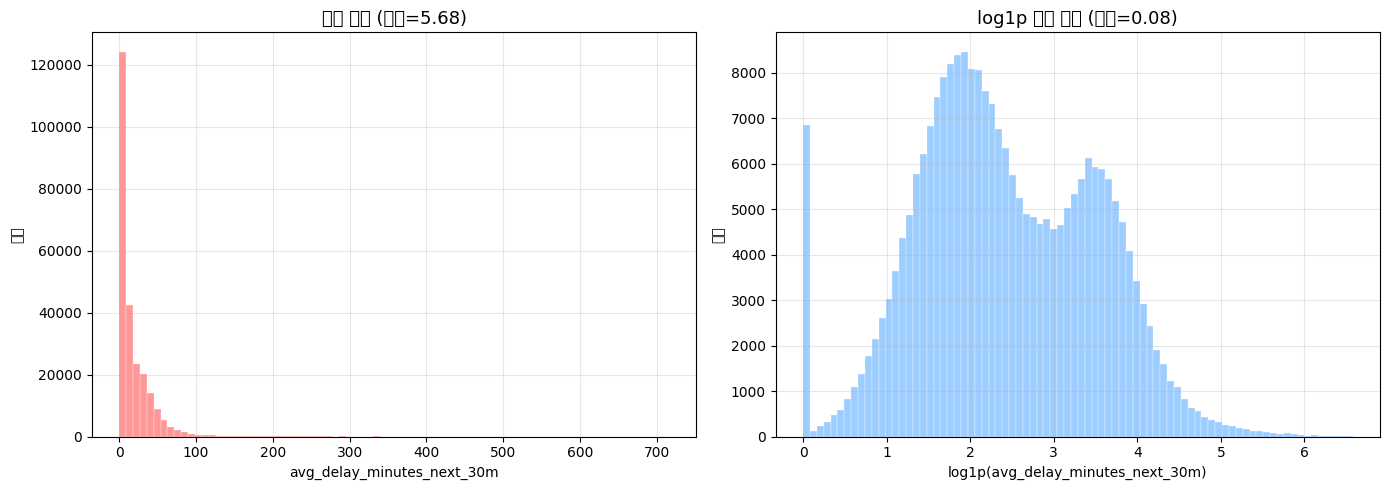

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=80, color='#FF6B6B', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[0].set_title(f'원본 타겟 (왜도={pd.Series(y).skew():.2f})', fontsize=13)
axes[0].set_xlabel('avg_delay_minutes_next_30m'); axes[0].set_ylabel('빈도')
axes[0].grid(alpha=0.3)

axes[1].hist(y_log, bins=80, color='#74B9FF', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[1].set_title(f'log1p 변환 타겟 (왜도={pd.Series(y_log).skew():.2f})', fontsize=13)
axes[1].set_xlabel('log1p(avg_delay_minutes_next_30m)'); axes[1].set_ylabel('빈도')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/log_transform_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. GroupKFold — 원본 타겟 학습 (베이스라인)

In [4]:
gkf = GroupKFold(n_splits=N_SPLITS)

oof_orig = np.zeros(len(train))
test_preds_orig = []
fold_maes_orig = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X[tr_idx], y[tr_idx],
              eval_set=[(X[val_idx], y[val_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_orig[val_idx] = model.predict(X[val_idx]).clip(0)
    test_preds_orig.append(model.predict(X_test).clip(0))
    mae = mean_absolute_error(y[val_idx], oof_orig[val_idx])
    fold_maes_orig.append(mae)
    print(f'  [원본] Fold {fold+1}: MAE={mae:.4f}, iter={model.best_iteration_}')

oof_mae_orig = mean_absolute_error(y, oof_orig)
print(f'\n[원본] OOF MAE = {oof_mae_orig:.4f} (std={np.std(fold_maes_orig):.4f})')


  [원본] Fold 1: MAE=9.1363, iter=630


  [원본] Fold 2: MAE=9.3006, iter=104


  [원본] Fold 3: MAE=8.8462, iter=182


  [원본] Fold 4: MAE=9.6078, iter=704


  [원본] Fold 5: MAE=9.1863, iter=81

[원본] OOF MAE = 9.2154 (std=0.2468)


## 5. GroupKFold — log1p 타겟 학습

In [5]:
oof_log = np.zeros(len(train))
test_preds_log = []
fold_maes_log = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y_log, groups=groups)):
    model_log = lgb.LGBMRegressor(**lgb_params)
    model_log.fit(X[tr_idx], y_log[tr_idx],
                  eval_set=[(X[val_idx], y_log[val_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])

    # 역변환: expm1 후 clip(0)
    pred_log = model_log.predict(X[val_idx])
    pred_orig = np.expm1(pred_log).clip(0)
    oof_log[val_idx] = pred_orig

    test_pred_log = model_log.predict(X_test)
    test_preds_log.append(np.expm1(test_pred_log).clip(0))

    mae = mean_absolute_error(y[val_idx], oof_log[val_idx])  # 원본 스케일 MAE
    fold_maes_log.append(mae)
    print(f'  [log1p] Fold {fold+1}: MAE={mae:.4f}, iter={model_log.best_iteration_}')

oof_mae_log = mean_absolute_error(y, oof_log)
print(f'\n[log1p] OOF MAE = {oof_mae_log:.4f} (std={np.std(fold_maes_log):.4f})')


  [log1p] Fold 1: MAE=9.1310, iter=178


  [log1p] Fold 2: MAE=9.3042, iter=189


  [log1p] Fold 3: MAE=8.8690, iter=217


  [log1p] Fold 4: MAE=9.6144, iter=316


  [log1p] Fold 5: MAE=9.1826, iter=93

[log1p] OOF MAE = 9.2203 (std=0.2430)


## 6. 결과 비교 시각화

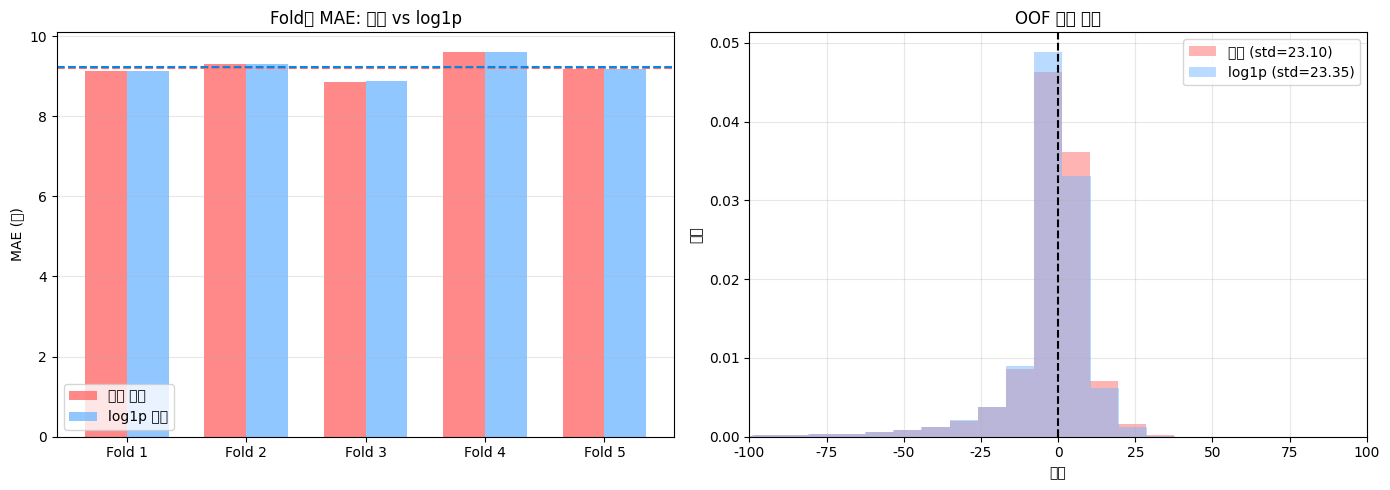

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fold별 MAE
x = np.arange(N_SPLITS)
width = 0.35
axes[0].bar(x - width/2, fold_maes_orig, width, label='원본 타겟', color='#FF6B6B', alpha=0.8)
axes[0].bar(x + width/2, fold_maes_log,  width, label='log1p 변환', color='#74B9FF', alpha=0.8)
axes[0].axhline(oof_mae_orig, color='#FF6B6B', linestyle='--', linewidth=1.5)
axes[0].axhline(oof_mae_log,  color='#0984E3', linestyle='--', linewidth=1.5)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
axes[0].set_ylabel('MAE (분)'); axes[0].set_title('Fold별 MAE: 원본 vs log1p')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# OOF 잔차 비교
res_orig = oof_orig - y
res_log  = oof_log  - y
axes[1].hist(res_orig, bins=80, alpha=0.5, color='#FF6B6B',
             label=f'원본 (std={res_orig.std():.2f})', density=True)
axes[1].hist(res_log,  bins=80, alpha=0.5, color='#74B9FF',
             label=f'log1p (std={res_log.std():.2f})', density=True)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlim(-100, 100)
axes[1].set_xlabel('잔차'); axes[1].set_ylabel('밀도')
axes[1].set_title('OOF 잔차 분포'); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 결론 및 제출 파일 생성

In [7]:
improvement = oof_mae_orig - oof_mae_log
improvement_pct = improvement / oof_mae_orig * 100

print('=' * 55)
print(f'  원본 타겟  OOF MAE : {oof_mae_orig:.4f} 분')
print(f'  log1p 변환 OOF MAE : {oof_mae_log:.4f} 분')
print(f'  개선량 (원본 - log1p): {improvement:+.4f} 분')
print(f'  개선율                : {improvement_pct:+.2f}%')
print('=' * 55)

if improvement > 0:
    print('✅ log1p 변환이 더 좋음 → 이후 실험에 log1p 고정')
    best_preds = np.mean(test_preds_log, axis=0)
    best_tag = 'log1p'
else:
    print('⚠️  원본이 더 좋음 → 원본 타겟 유지')
    best_preds = np.mean(test_preds_orig, axis=0)
    best_tag = 'orig'

submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
submission['avg_delay_minutes_next_30m'] = best_preds.clip(min=0)
out_path = f'../submissions/groupkfold_{best_tag}_lgbm.csv'
submission.to_csv(out_path, index=False)
print(f'\n제출 파일 저장: {out_path}')
print(f'예측 통계: 평균={best_preds.mean():.2f}, std={best_preds.std():.2f}')


  원본 타겟  OOF MAE : 9.2154 분
  log1p 변환 OOF MAE : 9.2203 분
  개선량 (원본 - log1p): -0.0048 분
  개선율                : -0.05%
⚠️  원본이 더 좋음 → 원본 타겟 유지

제출 파일 저장: ../submissions/groupkfold_orig_lgbm.csv
예측 통계: 평균=18.03, std=12.92


## 8. 다음 단계

- **Day 6 (04.09)**: `ts_idx`, `ts_ratio`, `ts_sin`, `ts_cos` 피처 추가  
  - ts_idx=0 → 11.3분, ts_idx=24 → 21.9분 선형 증가 확인됨
- **Week 2 (04.11~)**: Lag/Rolling/Expanding/Domain 피처 파이프라인
